# Model Comparison
Side-by-side benchmarking of Logistic Regression, Decision Tree, and KNN across Precision, Recall, F1-Score, and ROC-AUC.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Load data
credit_card_data = pd.read_csv('creditcard.csv' if os.path.exists('creditcard.csv') else 'creditcard.csv.zip')
print('Dataset Loaded Successfully ✅')
print(credit_card_data.shape)
print(credit_card_data['Class'].value_counts())


Dataset Loaded Successfully ✅
(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [2]:
X = credit_card_data.drop(columns='Class', axis=1)
y = credit_card_data['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train models
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(X_train, y_train)
dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42).fit(X_train, y_train)

y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_dt = dt.predict_proba(X_test)[:, 1]
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

results = pd.DataFrame({
    'Model': ['Logistic Regression (Balanced)', 'Decision Tree (depth=6)'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_dt)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_dt)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_dt)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_dt)]
})
display(results.round(4))


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Balanced),0.9716,0.0530,0.9184,0.1002,0.9721
1,Decision Tree (depth=6),0.9763,0.0585,0.8469,0.1094,0.8927


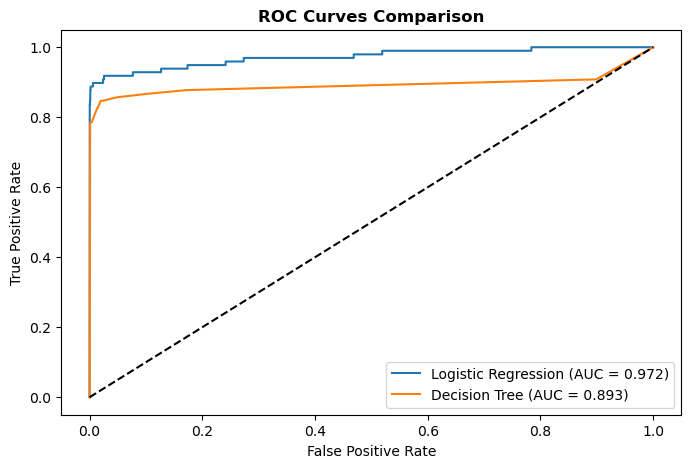

In [3]:
# ROC Curve Comparison
plt.figure(figsize=(8, 5))
for name, prob in [('Logistic Regression', y_prob_lr), ('Decision Tree', y_prob_dt)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, prob):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves Comparison', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()
